# DSMarket — Tarea 1: EDA e historia de negocio

<div style="background-color:#2d8c4e; border-left:6px solid #264653; padding:14px; border-radius:10px; color:white;">

**Objetivo del notebook**

El objetivo de este notebook es una lectura del negocio sobre la demanda de la empresa DSMarket.  
Nos enfocaremos en los siguientes puntos:

- Patrones temporales de ventas  
- Diferencias por ciudad y categoría  
- Priorización de riesgo operativo × impacto económico proxy  

Queremos dejar una base sólida y clara para las siguientes tareas del proyecto y poder responder a las necesidades del negocio.

</div>

<a id="indice"></a>

## Índice

1. [Setup y carga de datos](#setup)
2. [Validación inicial](#validacion-inicial)
3. [Serie temporal global](#serie-temporal-global)
4. [Patrón semanal de la demanda](#patron-semanal)
5. [Eventos y comportamiento de ventas](#eventos)
6. [Análisis por ciudad](#analisis-ciudad)
7. [Precio y demanda](#precio-demanda)
8. [Análisis por ciudad y categoría](#analisis-ciudad-categoria)
9. [Priorización riesgo × impacto](#priorizacion)
10. [Exportables ligeros](#exportables)
11. [Cierre ejecutivo](#cierre-ejecutivo)

## Cómo leer este notebook

La lógica del análisis sigue esta secuencia:

1. Entender el comportamiento agregado de la demanda,
2. Comprobar si existe una estructura semanal clara,
3. Revisar si los eventos aportan señal visible,
4. Bajar al nivel de ciudad y ciudad × categoría,
5. Identificar focos prioritarios para negocio.



[⬆ Volver al índice](#indice)

In [2]:
# =============================================================================
# Imports y configuración global
# =============================================================================

import os
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

SEED = 42
np.random.seed(SEED)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

COLORS = {
    "primary":   "#2D8C4E",
    "secondary": "#F4A261",
    "accent":    "#E76F51",
    "neutral":   "#8ECAE6",
    "dark":      "#264653",
}

print("✅ Configuración cargada")
print(f"Seed: {SEED}")

✅ Configuración cargada
Seed: 42


# =============================================================================
# Rutas portables del proyecto
# =============================================================================

<a id="setup"></a>

In [ ]:
# =============================================================================
# Rutas portables del proyecto
# =============================================================================

PROJECT_ROOT = Path.cwd()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DIR_DEFAULT = DATA_DIR / "raw"
INTERIM_DIR = DATA_DIR / "interim"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [INTERIM_DIR, PROCESSED_DIR, FIGURES_DIR, OUTPUTS_DIR, MODELS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

REQUIRED_FILES = {
    "daily_calendar_with_events.csv",
    "item_prices.csv",
    "item_sales.csv",
}

def has_required_files(folder: Path) -> bool:
    return folder.is_dir() and REQUIRED_FILES.issubset({p.name for p in folder.iterdir() if p.is_file()})

def build_candidate_raw_dirs() -> list[Path]:
    candidates = []

    env_raw = os.getenv("DSMARKET_RAW_DIR")
    if env_raw:
        candidates.append(Path(env_raw))

    candidates.extend([
        PROJECT_ROOT / "data" / "raw",
        PROJECT_ROOT / "raw",
        PROJECT_ROOT.parent / "data" / "raw",
        Path("/content/DSMarket/data/raw"),
        Path("/content/drive/MyDrive/TFM MASTER/TFM/Mateo/data/raw"),
        Path("/kaggle/input/dsmarket"),
        Path("/kaggle/input/datasets/mateopascual/dsmarket"),
    ])

    kaggle_input = Path("/kaggle/input")
    if kaggle_input.exists():
        for path in kaggle_input.iterdir():
            if path.is_dir():
                candidates.append(path)
                candidates.extend([sub for sub in path.iterdir() if sub.is_dir()])

    unique_candidates = []
    seen = set()

    for path in candidates:
        path = Path(path)
        if str(path) not in seen:
            unique_candidates.append(path)
            seen.add(str(path))

    return unique_candidates

def resolve_raw_dir() -> Path:
    candidates = build_candidate_raw_dirs()

    for candidate in candidates:
        if has_required_files(candidate):
            return candidate
        if has_required_files(candidate / "data" / "raw"):
            return candidate / "data" / "raw"
        if has_required_files(candidate / "raw"):
            return candidate / "raw"

    searched = "\n - ".join(str(p) for p in candidates[:20])
    raise FileNotFoundError(
        "No se encontró una carpeta válida con los archivos requeridos.\n"
        "Archivos esperados:\n"
        f" - {chr(10).join(sorted(REQUIRED_FILES))}\n\n"
        "Puedes definir manualmente la variable de entorno DSMARKET_RAW_DIR.\n"
        f"Primeras rutas revisadas:\n - {searched}"
    )

RAW_DIR = resolve_raw_dir()

print("✅ Rutas resueltas")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

✅ Rutas resueltas
PROJECT_ROOT: /kaggle/working
RAW_DIR: /kaggle/input/datasets/mateopascual/dsmarket
PROCESSED_DIR: /kaggle/working/data/processed
FIGURES_DIR: /kaggle/working/reports/figures


In [ ]:
# =============================================================================
# Carga de datos
# =============================================================================

df_cal = pd.read_csv(
    RAW_DIR / "daily_calendar_with_events.csv",
    parse_dates=["date"],
    low_memory=False
)

df_prices = pd.read_csv(
    RAW_DIR / "item_prices.csv",
    low_memory=False
)

df_sales = pd.read_csv(
    RAW_DIR / "item_sales.csv",
    low_memory=False
)

print("✅ Datos cargados")
print("df_cal   :", df_cal.shape)
print("df_prices:", df_prices.shape)
print("df_sales :", df_sales.shape)

✅ Datos cargados
df_cal   : (1913, 5)
df_prices: (6965706, 5)
df_sales : (30490, 1920)


<a id="validacion-inicial"></a>

## Validación inicial

Antes de entrar en el análisis, verificamos que los tres datasets principales están cargados correctamente,
que las columnas clave existen y que no hay problemas básicos de estructura.

[⬆ Volver al índice](#indice)


In [ ]:
# =============================================================================
# Validación inicial de estructura
# =============================================================================

def resumen_dataframe(df: pd.DataFrame, nombre: str, date_col: str | None = None) -> None:
    memoria_mb = df.memory_usage(deep=True).sum() / 1e6
    print(f"\n{'=' * 72}")
    print(nombre)
    print(f"{'=' * 72}")
    print(f"Shape: {df.shape[0]:,} filas × {df.shape[1]:,} columnas")
    print(f"Memoria: {memoria_mb:,.2f} MB")

    if date_col and date_col in df.columns:
        print(f"Rango temporal: {df[date_col].min()} → {df[date_col].max()}")

    print("\nTipos de datos:")
    print(df.dtypes.astype(str).value_counts())

    nulls = df.isna().sum()
    nulls = nulls[nulls > 0].sort_values(ascending=False)

    if len(nulls) == 0:
        print("\nNulos: 0 ✅")
    else:
        print("\nTop nulos:")
        display(nulls.head(10).to_frame("n_nulls"))

resumen_dataframe(df_cal, "df_cal", date_col="date")
resumen_dataframe(df_prices, "df_prices")
resumen_dataframe(df_sales, "df_sales")



df_cal
Shape: 1,913 filas × 5 columnas
Memoria: 0.30 MB
Rango temporal: 2011-01-29 00:00:00 → 2016-04-24 00:00:00

Tipos de datos:
object            3
datetime64[ns]    1
int64             1
Name: count, dtype: int64

Top nulos:


,n_nulls
event,1887



df_prices
Shape: 6,965,706 filas × 5 columnas
Memoria: 1,372.34 MB

Tipos de datos:
object     3
float64    2
Name: count, dtype: int64

Top nulos:


,n_nulls
yearweek,243920



df_sales
Shape: 30,490 filas × 1,920 columnas
Memoria: 479.80 MB

Tipos de datos:
int64     1913
object       7
Name: count, dtype: int64

Nulos: 0 ✅


In [ ]:
# =============================================================================
# Revisión de columnas clave
# =============================================================================

calendar_required = {"date", "d"}
prices_required_min = {"item", "store_code"}
sales_required_min = {"item", "store_code", "category"}

missing_cal = calendar_required - set(df_cal.columns)
missing_prices = prices_required_min - set(df_prices.columns)
missing_sales = sales_required_min - set(df_sales.columns)

if missing_cal:
    raise ValueError(f"Faltan columnas en df_cal: {missing_cal}")

if missing_prices:
    raise ValueError(f"Faltan columnas en df_prices: {missing_prices}")

if missing_sales:
    raise ValueError(f"Faltan columnas en df_sales: {missing_sales}")

day_cols = [col for col in df_sales.columns if re.fullmatch(r"d_\d+", str(col))]
day_cols = sorted(day_cols, key=lambda x: int(str(x).split("_")[1]))

if not day_cols:
    raise ValueError("No se detectaron columnas diarias tipo d_1, d_2, ... en df_sales")

print("✅ Columnas clave validadas")
print(f"Número de columnas diarias en df_sales: {len(day_cols):,}")

display(df_cal.head(3))
display(df_prices.head(3))
display(df_sales.head(3))

✅ Columnas clave validadas
Número de columnas diarias en df_sales: 1,913


,date,weekday,weekday_int,d,event
0,2011-01-29,Saturday,1,d_1,NaN
1,2011-01-30,Sunday,2,d_2,NaN
2,2011-01-31,Monday,3,d_3,NaN


,item,category,store_code,yearweek,sell_price
0,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,328.00",12.74
1,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,329.00",12.74
2,ACCESORIES_1_001,ACCESORIES,NYC_1,"201,330.00",10.99


,id,item,category,department,store,store_code,region,d_1,d_2,d_3,d_4,d_5,d_6,d_7,d_8,d_9,d_10,d_11,d_12,d_13,d_14,d_15,d_16,d_17,d_18,d_19,d_20,d_21,d_22,d_23,d_24,d_25,d_26,d_27,d_28,d_29,d_30,d_31,d_32,d_33,d_34,d_35,d_36,d_37,d_38,d_39,d_40,d_41,d_42,d_43,d_44,d_45,d_46,d_47,d_48,d_49,d_50,d_51,d_52,d_53,...,d_1854,d_1855,d_1856,d_1857,d_1858,d_1859,d_1860,d_1861,d_1862,d_1863,d_1864,d_1865,d_1866,d_1867,d_1868,d_1869,d_1870,d_1871,d_1872,d_1873,d_1874,d_1875,d_1876,d_1877,d_1878,d_1879,d_1880,d_1881,d_1882,d_1883,d_1884,d_1885,d_1886,d_1887,d_1888,d_1889,d_1890,d_1891,d_1892,d_1893,d_1894,d_1895,d_1896,d_1897,d_1898,d_1899,d_1900,d_1901,d_1902,d_1903,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,ACCESORIES_1_001_NYC_1,ACCESORIES_1_001,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,1,4,2,0,2,0,1,1,0,1,0,0,1,1,3,0,0,0,1,1,1,3,1,3,1,2,2,0,1,1,1,1,0,0,0,0,0,1,0,4,2,3,0,1,2,0,0,0,1,1,3,0,1,1,1,3,0,1,1
1,ACCESORIES_1_002_NYC_1,ACCESORIES_1_002,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,1,0,0,1,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
2,ACCESORIES_1_003_NYC_1,ACCESORIES_1_003,ACCESORIES,ACCESORIES_1,Greenwich_Village,NYC_1,New York,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,6,1,1,2,0,0,0,1,1,0,0,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,2,2,1,2,1,1,1,0,1,1,1


<a id="serie-temporal-global"></a>

## Serie temporal global

En este bloque analizamos la evolución agregada de la demanda diaria para entender
si el negocio presenta una estructura temporal reconocible o si, por el contrario,
la variación observada se parece más a ruido sin patrón claro.

La lectura aquí es importante porque condiciona el resto del proyecto:
si la demanda tiene forma, ritmo y recurrencia, entonces tiene sentido
pasar después a forecasting y priorización con una base más sólida.

[⬆ Volver al índice](#indice)

In [ ]:
# =============================================================================
# Construcción de la serie diaria global
# =============================================================================

df_cal2 = df_cal.copy()
df_cal2["date"] = pd.to_datetime(df_cal2["date"], errors="coerce")

df_cal2["d_key"] = df_cal2["d"].astype(str)
mask_no_prefix = ~df_cal2["d_key"].str.startswith("d_")
df_cal2.loc[mask_no_prefix, "d_key"] = "d_" + df_cal2.loc[mask_no_prefix, "d_key"]

daily_total_units = df_sales[day_cols].sum(axis=0)

df_daily = pd.DataFrame({
    "d_key": daily_total_units.index.astype(str),
    "total_units": daily_total_units.values
})

calendar_cols = ["d_key", "date"]
df_daily = df_daily.merge(
    df_cal2[calendar_cols],
    on="d_key",
    how="left"
)

n_missing_dates = int(df_daily["date"].isna().sum())
if n_missing_dates > 0:
    examples = df_daily.loc[df_daily["date"].isna(), "d_key"].head(10).tolist()
    raise ValueError(
        f"El merge entre ventas diarias y calendario dejó fechas nulas: {n_missing_dates}. "
        f"Ejemplos: {examples}"
    )

df_daily = df_daily.sort_values("date").reset_index(drop=True)
df_daily["ma_7"] = df_daily["total_units"].rolling(7, min_periods=1).mean()
df_daily["ma_28"] = df_daily["total_units"].rolling(28, min_periods=1).mean()

print("✅ Serie diaria global construida")
print("Shape:", df_daily.shape)
print("Rango temporal:", df_daily["date"].min(), "→", df_daily["date"].max())
display(df_daily.head(10))

✅ Serie diaria global construida
Shape: (1913, 5)
Rango temporal: 2011-01-29 00:00:00 → 2016-04-24 00:00:00


,d_key,total_units,date,ma_7,ma_28
0,d_1,32631,2011-01-29,"32,631.00","32,631.00"
1,d_2,31749,2011-01-30,"32,190.00","32,190.00"
2,d_3,23783,2011-01-31,"29,387.67","29,387.67"
3,d_4,25412,2011-02-01,"28,393.75","28,393.75"
4,d_5,19146,2011-02-02,"26,544.20","26,544.20"
5,d_6,29211,2011-02-03,"26,988.67","26,988.67"
6,d_7,28010,2011-02-04,"27,134.57","27,134.57"
7,d_8,37932,2011-02-05,"27,891.86","28,484.25"
8,d_9,32736,2011-02-06,"28,032.86","28,956.67"
9,d_10,25572,2011-02-07,"28,288.43","28,618.20"


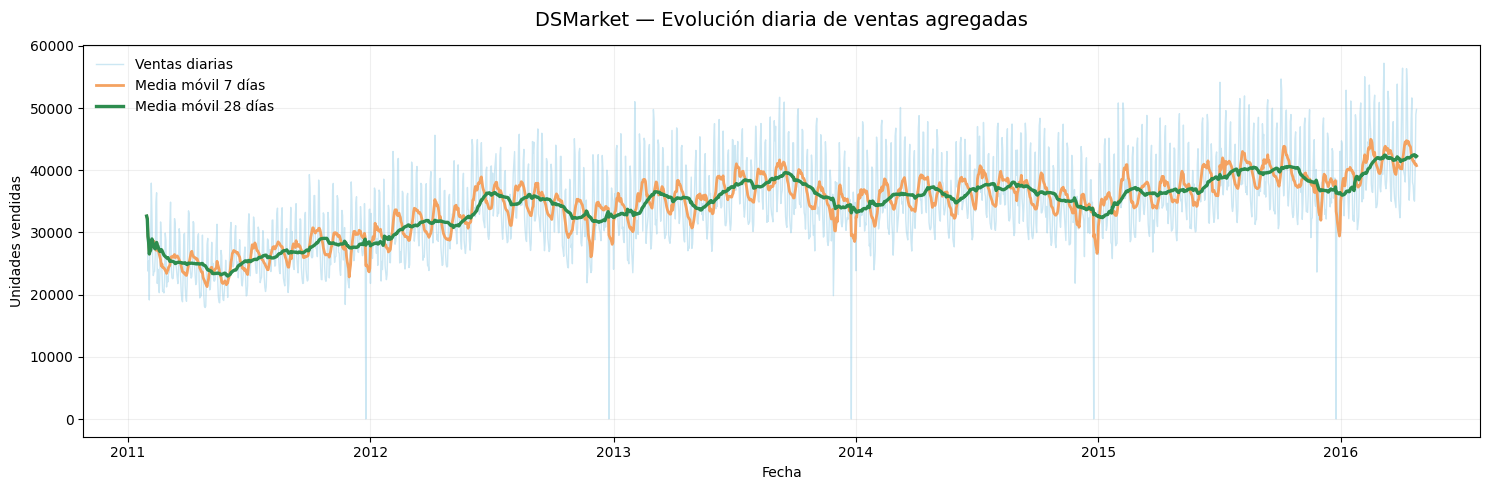

📊 Resumen de ventas diarias agregadas


,mean,std,min,25%,50%,75%,max
total_units,"34,341.56","7,345.91",11.00,"29,654.00","33,732.00","38,689.00","57,218.00"


In [ ]:
# =============================================================================
# Visualización de la serie diaria global
# =============================================================================

fig, ax = plt.subplots(figsize=(15, 5))

ax.plot(
    df_daily["date"],
    df_daily["total_units"],
    linewidth=1.0,
    alpha=0.45,
    color=COLORS["neutral"],
    label="Ventas diarias"
)

ax.plot(
    df_daily["date"],
    df_daily["ma_7"],
    linewidth=2.0,
    color=COLORS["secondary"],
    label="Media móvil 7 días"
)

ax.plot(
    df_daily["date"],
    df_daily["ma_28"],
    linewidth=2.4,
    color=COLORS["primary"],
    label="Media móvil 28 días"
)

ax.set_title("DSMarket — Evolución diaria de ventas agregadas", fontsize=14, pad=14)
ax.set_xlabel("Fecha")
ax.set_ylabel("Unidades vendidas")
ax.grid(alpha=0.20)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

summary_daily = (
    df_daily["total_units"]
    .describe()[["mean", "std", "min", "25%", "50%", "75%", "max"]]
    .to_frame()
    .T
    .round(2)
)

print("📊 Resumen de ventas diarias agregadas")
display(summary_daily)

<a id="patron-semanal"></a>

## Patrón semanal de la demanda

Después de revisar la serie agregada, el siguiente paso es comprobar
si existe una estructura semanal clara.

Es importante comprobar si hay una pauta estable por dia de la semana
ya que puede ser útil tanto para interpretar el negocio como para 
apoyer el diseño posterior del forecasting. 


[⬆ Volver al índice](#indice)

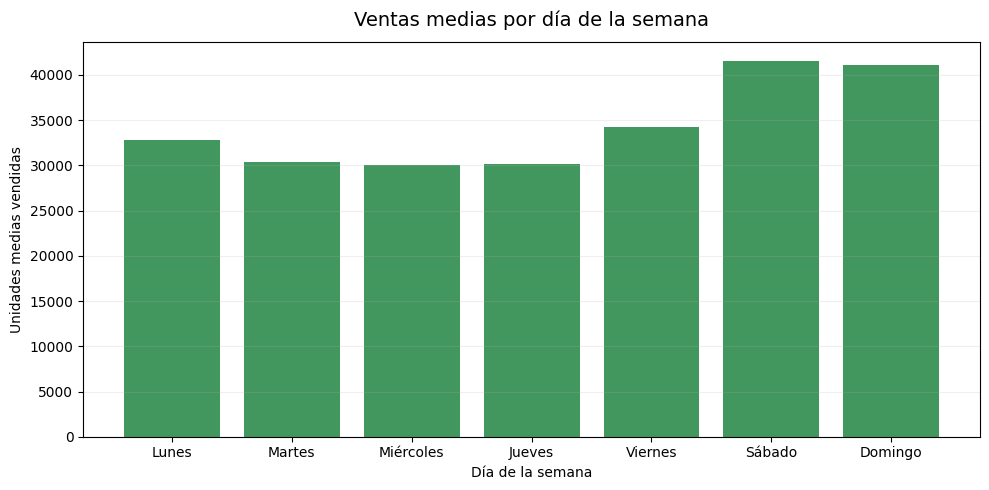

📊 Resumen semanal


,weekday_int,weekday_name,mean_units,median_units,std_units
0,0,Lunes,"32,852.97","33,444.00","5,223.53"
1,1,Martes,"30,368.78","30,710.00","5,088.43"
2,2,Miércoles,"30,010.02","30,911.00","5,164.11"
3,3,Jueves,"30,205.01","30,658.00","5,342.80"
4,4,Viernes,"34,225.99","34,775.00","5,602.04"
5,5,Sábado,"41,546.89","42,437.00","6,120.41"
6,6,Domingo,"41,130.02","42,586.00","6,997.73"


In [ ]:
# =============================================================================
# Patrón semanal de la demanda
# =============================================================================

weekday_map = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo",
}

df_daily["weekday_int"] = df_daily["date"].dt.weekday
df_daily["weekday_name"] = df_daily["weekday_int"].map(weekday_map)

weekday_summary = (
    df_daily.groupby(["weekday_int", "weekday_name"], as_index=False)["total_units"]
    .agg(mean_units="mean", median_units="median", std_units="std")
    .sort_values("weekday_int")
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    weekday_summary["weekday_name"],
    weekday_summary["mean_units"],
    color=COLORS["primary"],
    alpha=0.90
)

ax.set_title("Ventas medias por día de la semana", fontsize=14, pad=12)
ax.set_xlabel("Día de la semana")
ax.set_ylabel("Unidades medias vendidas")
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

print("📊 Resumen semanal")
display(weekday_summary.round(2))

<a id="eventos"></a>

## Eventos y comportamiento de ventas

Queremos revisar si el dato de eventos pueda aportar alguna
señal visible sobre la demanda agregada.

Queremos comprobar si esta variable merece atención como 
señal contextual dentro del análisis de negocio. 


[⬆ Volver al índice](#indice)

In [ ]:
# =============================================================================
# Construcción de indicador de evento
# =============================================================================

event_name_cols = [col for col in df_cal2.columns if "event" in col.lower() and "name" in col.lower()]

if "event" in df_cal2.columns:
    df_cal2["event_flag"] = (
        df_cal2["event"]
        .fillna("")
        .astype(str)
        .str.strip()
        .replace({"": "No evento"})
    )
elif event_name_cols:
    df_cal2["event_flag"] = (
        df_cal2[event_name_cols]
        .fillna("")
        .astype(str)
        .agg(" | ".join, axis=1)
        .str.strip(" |")
        .replace({"": "No evento"})
    )
else:
    df_cal2["event_flag"] = "No evento"

df_cal2["has_event"] = df_cal2["event_flag"].ne("No evento")

df_daily = df_daily.drop(columns=["event_flag", "has_event"], errors="ignore")

df_daily = df_daily.merge(
    df_cal2[["d_key", "event_flag", "has_event"]],
    on="d_key",
    how="left"
)

df_daily["event_flag"] = df_daily["event_flag"].fillna("No evento")
df_daily["has_event"] = df_daily["has_event"].fillna(False)

print("✅ Indicador de evento preparado")
display(df_daily[["date", "event_flag", "has_event"]].head(10))

✅ Indicador de evento preparado


,date,event_flag,has_event
0,2011-01-29,No evento,False
1,2011-01-30,No evento,False
2,2011-01-31,No evento,False
3,2011-02-01,No evento,False
4,2011-02-02,No evento,False
5,2011-02-03,No evento,False
6,2011-02-04,No evento,False
7,2011-02-05,No evento,False
8,2011-02-06,SuperBowl,True
9,2011-02-07,No evento,False


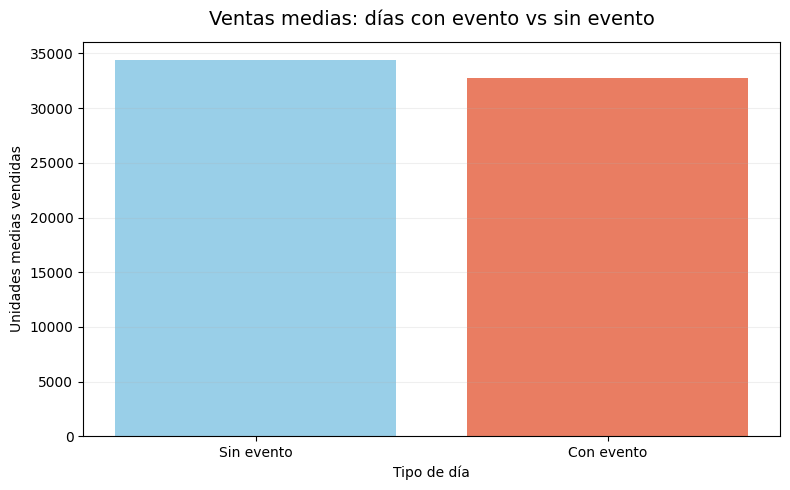

📊 Resumen con evento vs sin evento


,has_event,mean_units,median_units,std_units,n_days,label
0,False,"34,363.48","33,714.00","7,323.37",1887,Sin evento
1,True,"32,750.85","34,436.50","8,854.05",26,Con evento


In [ ]:
# =============================================================================
# Comparación entre días con evento y sin evento
# =============================================================================

event_summary = (
    df_daily.groupby("has_event", as_index=False)["total_units"]
    .agg(mean_units="mean", median_units="median", std_units="std", n_days="count")
)

event_summary["label"] = event_summary["has_event"].map({
    False: "Sin evento",
    True: "Con evento"
})

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    event_summary["label"],
    event_summary["mean_units"],
    color=[COLORS["neutral"], COLORS["accent"]],
    alpha=0.90
)

ax.set_title("Ventas medias: días con evento vs sin evento", fontsize=14, pad=12)
ax.set_xlabel("Tipo de día")
ax.set_ylabel("Unidades medias vendidas")
ax.grid(axis="y", alpha=0.20)

plt.tight_layout()
plt.show()

print("📊 Resumen con evento vs sin evento")
display(event_summary.round(2))

In [ ]:
# =============================================================================
# Eventos más frecuentes en el calendario
# =============================================================================

top_events = (
    df_daily.loc[df_daily["has_event"]]
    .groupby("event_flag", as_index=False)["total_units"]
    .agg(mean_units="mean", n_days="count")
    .sort_values(["n_days", "mean_units"], ascending=[False, False])
    .reset_index(drop=True)
)

print("📊 Eventos más frecuentes")
display(top_events.head(10).round(2))

📊 Eventos más frecuentes


,event_flag,mean_units,n_days
0,SuperBowl,"40,924.00",6
1,Easter,"39,517.60",5
2,Ramadan starts,"34,779.60",5
3,NewYear,"25,768.40",5
4,Thanksgiving,"21,130.00",5


<a id="analisis-ciudad"></a>

## Análisis por ciudad

Antes de bajar al nivel geográfico, dejamos preparada la tabla de precios semanal limpia.

Esto es importante porque cualquier duplicado o semana nula en precios puede contaminar
los joins posteriores con demanda y producir errores silenciosos.

[⬆ Volver al índice](#indice)

In [ ]:
# =============================================================================
# Limpieza de item_prices: deduplicación y nulls (item × store × week)
# =============================================================================

if "yearweek" not in df_prices.columns:
    raise ValueError("df_prices no tiene la columna 'yearweek'.")

if "sell_price" not in df_prices.columns:
    raise ValueError("df_prices no tiene la columna 'sell_price'.")

df_prices_clean = df_prices.dropna(subset=["yearweek"]).copy()
df_prices_clean["yearweek"] = pd.to_numeric(df_prices_clean["yearweek"], errors="coerce")

if df_prices_clean["yearweek"].isna().any():
    raise ValueError("Hay yearweek no convertibles a numérico en df_prices.")

df_prices_clean["yearweek"] = df_prices_clean["yearweek"].round().astype(int)

df_prices_clean = (
    df_prices_clean
    .groupby(["item", "store_code", "yearweek"], observed=True, as_index=False)["sell_price"]
    .mean()
)

print("✅ df_prices_clean creado")
print("Shape:", df_prices_clean.shape)
display(df_prices_clean.head(10))

✅ df_prices_clean creado
Shape: (6721786, 4)


,item,store_code,yearweek,sell_price
0,ACCESORIES_1_001,BOS_1,201328,12.74
1,ACCESORIES_1_001,BOS_1,201329,10.99
2,ACCESORIES_1_001,BOS_1,201330,10.99
3,ACCESORIES_1_001,BOS_1,201331,10.99
4,ACCESORIES_1_001,BOS_1,201332,10.99
5,ACCESORIES_1_001,BOS_1,201333,10.99
6,ACCESORIES_1_001,BOS_1,201334,10.99
7,ACCESORIES_1_001,BOS_1,201335,10.99
8,ACCESORIES_1_001,BOS_1,201336,10.99
9,ACCESORIES_1_001,BOS_1,201337,10.99


In [ ]:
# =============================================================================
# Ventas semanales por tienda (store_code × yearweek) sin melt masivo
# =============================================================================

if "store_code" not in df_sales.columns:
    raise ValueError("df_sales no tiene 'store_code'.")

if not {"d_key", "date"}.issubset(df_cal2.columns):
    raise ValueError("df_cal2 debe tener columnas ['d_key', 'date'].")

df_cal_yw = df_cal2[["d_key", "date"]].copy()
iso = df_cal_yw["date"].dt.isocalendar()
df_cal_yw["yearweek"] = (iso["year"].astype(int) * 100 + iso["week"].astype(int)).astype("int32")
df_cal_yw = df_cal_yw[["d_key", "yearweek"]].drop_duplicates()

df_store_daily = df_sales.groupby("store_code", observed=True)[day_cols].sum()

df_store_long = (
    df_store_daily
    .stack()
    .reset_index(name="units_day")
    .rename(columns={"level_1": "d_key"})
)

df_store_long["d_key"] = df_store_long["d_key"].astype(str)

df_store_long = df_store_long.merge(
    df_cal_yw,
    on="d_key",
    how="left"
)

if df_store_long["yearweek"].isna().any():
    bad = df_store_long.loc[df_store_long["yearweek"].isna(), "d_key"].head(10).tolist()
    raise ValueError(f"Hay d_key sin yearweek tras el merge con calendario. Ejemplos: {bad}")

df_store_weekly = (
    df_store_long
    .groupby(["store_code", "yearweek"], observed=True, as_index=False)["units_day"]
    .sum()
    .rename(columns={"units_day": "units_week"})
)

print("✅ df_store_weekly creado")
print("Shape:", df_store_weekly.shape)
display(df_store_weekly.head(10))

✅ df_store_weekly creado
Shape: (2740, 3)


,store_code,yearweek,units_week
0,BOS_1,201104,5243
1,BOS_1,201105,15906
2,BOS_1,201106,16457
3,BOS_1,201107,15253
4,BOS_1,201108,14755
5,BOS_1,201109,15290
6,BOS_1,201110,15629
7,BOS_1,201111,16208
8,BOS_1,201112,14762
9,BOS_1,201113,15384


In [ ]:
# =============================================================================
# Mapeo store_code → city + cobertura (tiendas y semanas)
# =============================================================================

required = {"store_code", "yearweek", "units_week"}
missing = required - set(df_store_weekly.columns)
if missing:
    raise ValueError(f"df_store_weekly no tiene columnas requeridas: {missing}")

df_store_weekly2 = df_store_weekly.copy()

df_store_weekly2["city"] = (
    df_store_weekly2["store_code"]
    .astype(str)
    .str.split("_", n=1, expand=True)[0]
    .str.upper()
    .str.strip()
)

cities = sorted(df_store_weekly2["city"].dropna().unique().tolist())
print("✅ Ciudades detectadas:", cities)
print("✅ Nº ciudades:", df_store_weekly2["city"].nunique())

city_store_counts = (
    df_store_weekly2[["city", "store_code"]]
    .drop_duplicates()
    .groupby("city", observed=True)["store_code"]
    .nunique()
    .reset_index(name="n_stores")
    .sort_values("city")
)

city_week_counts = (
    df_store_weekly2.groupby("city", observed=True)["yearweek"]
    .nunique()
    .reset_index(name="n_weeks")
    .sort_values("city")
)

print("📊 Tiendas por ciudad")
display(city_store_counts)

print("📊 Cobertura temporal por ciudad")
display(city_week_counts)

✅ Ciudades detectadas: ['BOS', 'NYC', 'PHI']
✅ Nº ciudades: 3
📊 Tiendas por ciudad


,city,n_stores
0,BOS,3
1,NYC,4
2,PHI,3


📊 Cobertura temporal por ciudad


,city,n_weeks
0,BOS,274
1,NYC,274
2,PHI,274


📊 Cobertura semanal por ciudad


,n_weeks
city,
BOS,274
NYC,274
PHI,274


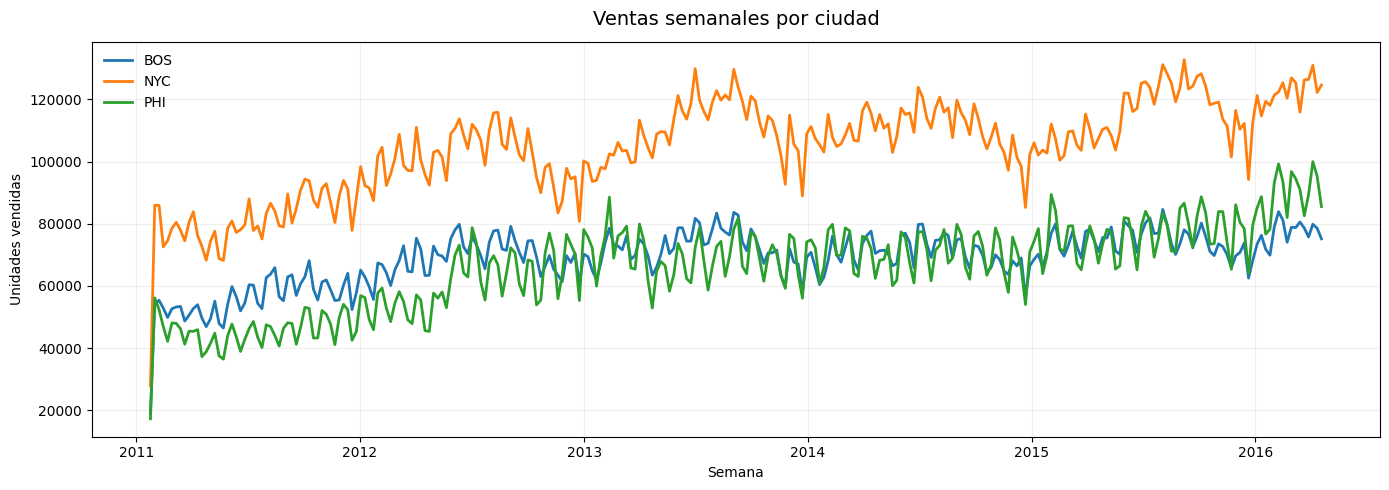

In [ ]:
# =============================================================================
# Agregación city × week + plot temporal (week_dt)
# =============================================================================

required = {"city", "yearweek", "units_week"}
missing = required - set(df_store_weekly2.columns)
if missing:
    raise ValueError(f"df_store_weekly2 no tiene columnas requeridas: {missing}")

df_city_weekly = (
    df_store_weekly2
    .groupby(["city", "yearweek"], observed=True, as_index=False)["units_week"]
    .sum()
)

def parse_yearweek_to_monday(yw: pd.Series) -> pd.Series:
    s = yw.astype(str).str.strip()
    year = s.str.slice(0, 4)
    week = s.str.slice(4, 6)
    return pd.to_datetime(year + "-W" + week + "-1", format="%G-W%V-%u", errors="coerce")

df_city_weekly["week_dt"] = parse_yearweek_to_monday(df_city_weekly["yearweek"])

if df_city_weekly["week_dt"].isna().any():
    bad = df_city_weekly.loc[df_city_weekly["week_dt"].isna(), "yearweek"].head(10).tolist()
    raise ValueError(f"Error creando week_dt. Ejemplos yearweek: {bad}")

df_city_weekly = df_city_weekly.sort_values(["city", "week_dt"]).reset_index(drop=True)

coverage = (
    df_city_weekly.groupby("city", observed=True)["yearweek"]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("n_weeks")
)

print("📊 Cobertura semanal por ciudad")
display(coverage)

fig, ax = plt.subplots(figsize=(14, 5))

for city, sub in df_city_weekly.groupby("city", observed=True):
    ax.plot(sub["week_dt"], sub["units_week"], linewidth=2.0, label=city)

ax.set_title("Ventas semanales por ciudad", fontsize=14, pad=12)
ax.set_xlabel("Semana")
ax.set_ylabel("Unidades vendidas")
ax.grid(alpha=0.20)
ax.legend(frameon=False)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# Ranking por ciudad (total units + share global)
# =============================================================================

required = {"city", "units_week"}
missing = required - set(df_city_weekly.columns)
if missing:
    raise ValueError(f"df_city_weekly no tiene columnas requeridas: {missing}")

city_totals = (
    df_city_weekly.groupby("city", observed=True, as_index=False)["units_week"]
    .sum()
    .rename(columns={"units_week": "total_units"})
    .sort_values("total_units", ascending=False)
    .reset_index(drop=True)
)

total_all = city_totals["total_units"].sum()
city_totals["share_pct"] = (city_totals["total_units"] / total_all) * 100
city_totals["rank"] = np.arange(1, len(city_totals) + 1)
city_totals["share_pct"] = city_totals["share_pct"].round(2)

display(city_totals)

top_city = city_totals.iloc[0].to_dict()
print("\nINTENCIONES:")
print(f"1) Ciudad #1 por volumen: {top_city['city']} ({top_city['total_units']:,.0f} units, {top_city['share_pct']:.2f}% share).")
print("2) Esto orienta priorización operativa a nivel ciudad.")
print("3) Próximo paso: añadir pricing por ciudad y revisar relación precio-demanda.")

,city,total_units,share_pct,rank
0,NYC,28675547,43.65,1
1,BOS,18899006,28.77,2
2,PHI,18120856,27.58,3



INTENCIONES:
1) Ciudad #1 por volumen: NYC (28,675,547 units, 43.65% share).
2) Esto orienta priorización operativa a nivel ciudad.
3) Próximo paso: añadir pricing por ciudad y revisar relación precio-demanda.


<a id="precio-demanda"></a>

## Precio y demanda

Ahora enriquecemos la serie semanal por ciudad con un precio medio semanal
y construimos un revenue proxy.

Importante: este análisis es descriptivo.
No sirve para afirmar elasticidad ni causalidad, pero sí para comprobar
si el precio medio semanal parece ser una señal útil a este nivel.

[⬆ Volver al índice](#indice)


In [ ]:
# =============================================================================
# Construcción y unión City × Week (units + avg_price_week + revenue proxy)
# =============================================================================

req_city_weekly = {"city", "yearweek", "units_week", "week_dt"}
req_prices = {"store_code", "yearweek", "sell_price"}

miss_cw = req_city_weekly - set(df_city_weekly.columns)
miss_p = req_prices - set(df_prices_clean.columns)

if miss_cw:
    raise ValueError(f"df_city_weekly no tiene columnas requeridas: {miss_cw}")
if miss_p:
    raise ValueError(f"df_prices_clean no tiene columnas requeridas: {miss_p}")

df_prices_city = df_prices_clean.copy()
df_prices_city["city"] = (
    df_prices_city["store_code"]
    .astype(str)
    .str.split("_", n=1, expand=True)[0]
    .str.upper()
    .str.strip()
)

df_city_price_weekly = (
    df_prices_city
    .groupby(["city", "yearweek"], observed=True, as_index=False)["sell_price"]
    .mean()
    .rename(columns={"sell_price": "avg_price_week"})
)

df_city_weekly_enriched = df_city_weekly.merge(
    df_city_price_weekly,
    on=["city", "yearweek"],
    how="left"
)

df_city_weekly_enriched["revenue_week_proxy"] = (
    df_city_weekly_enriched["units_week"] * df_city_weekly_enriched["avg_price_week"]
)

n_missing_price = int(df_city_weekly_enriched["avg_price_week"].isna().sum())
print("✅ df_city_weekly_enriched creado")
print("Shape:", df_city_weekly_enriched.shape)
print(f"Missing avg_price_week: {n_missing_price:,} ({n_missing_price/len(df_city_weekly_enriched)*100:.2f}%)")
display(df_city_weekly_enriched.head(10))

✅ df_city_weekly_enriched creado
Shape: (822, 6)
Missing avg_price_week: 6 (0.73%)


,city,yearweek,units_week,week_dt,avg_price_week,revenue_week_proxy
0,BOS,201104,19068,2011-01-24,NaN,NaN
1,BOS,201105,54119,2011-01-31,4.97,"269,149.62"
2,BOS,201106,55400,2011-02-07,5.08,"281,392.79"
3,BOS,201107,52847,2011-02-14,5.14,"271,520.98"
4,BOS,201108,49872,2011-02-21,5.14,"256,551.08"
5,BOS,201109,52666,2011-02-28,5.15,"271,123.38"
6,BOS,201110,53254,2011-03-07,5.15,"274,490.55"
7,BOS,201111,53432,2011-03-14,5.18,"276,679.44"
8,BOS,201112,48728,2011-03-21,5.19,"252,988.10"
9,BOS,201113,50626,2011-03-28,5.19,"262,769.42"


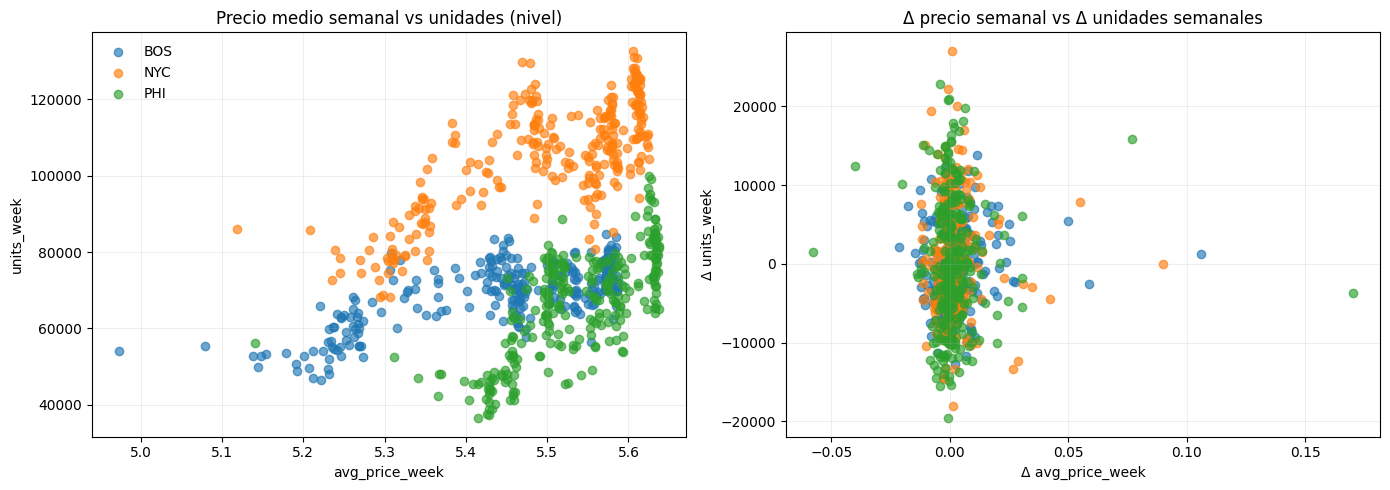

In [ ]:
# =============================================================================
# Scatter precio vs unidades (nivel) + diferencias semanales por ciudad
# =============================================================================

required = {"city", "week_dt", "units_week", "avg_price_week"}
missing = required - set(df_city_weekly_enriched.columns)
if missing:
    raise ValueError(f"df_city_weekly_enriched no tiene columnas requeridas: {missing}")

df_sc = (
    df_city_weekly_enriched
    .dropna(subset=["avg_price_week"])
    .copy()
    .sort_values(["city", "week_dt"])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for city, sub in df_sc.groupby("city", observed=True):
    axes[0].scatter(
        sub["avg_price_week"],
        sub["units_week"],
        alpha=0.65,
        label=city
    )

axes[0].set_title("Precio medio semanal vs unidades (nivel)")
axes[0].set_xlabel("avg_price_week")
axes[0].set_ylabel("units_week")
axes[0].grid(alpha=0.20)
axes[0].legend(frameon=False)

df_sc["delta_units"] = df_sc.groupby("city", observed=True)["units_week"].diff()
df_sc["delta_price"] = df_sc.groupby("city", observed=True)["avg_price_week"].diff()

df_sc_diff = df_sc.dropna(subset=["delta_units", "delta_price"]).copy()

for city, sub in df_sc_diff.groupby("city", observed=True):
    axes[1].scatter(
        sub["delta_price"],
        sub["delta_units"],
        alpha=0.65,
        label=city
    )

axes[1].set_title("Δ precio semanal vs Δ unidades semanales")
axes[1].set_xlabel("Δ avg_price_week")
axes[1].set_ylabel("Δ units_week")
axes[1].grid(alpha=0.20)

plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# Correlación precio-demanda por ciudad (nivel y diferencias)
# =============================================================================

required = {"city", "week_dt", "units_week", "avg_price_week"}
missing = required - set(df_city_weekly_enriched.columns)
if missing:
    raise ValueError(f"df_city_weekly_enriched no tiene columnas requeridas: {missing}")

df_corr_input = (
    df_city_weekly_enriched
    .dropna(subset=["avg_price_week"])
    .copy()
    .sort_values(["city", "week_dt"])
)

rows = []

for city, sub in df_corr_input.groupby("city", observed=True):
    corr_level = sub[["avg_price_week", "units_week"]].corr().iloc[0, 1]

    sub = sub.copy()
    sub["delta_units"] = sub["units_week"].diff()
    sub["delta_price"] = sub["avg_price_week"].diff()

    sub_diff = sub.dropna(subset=["delta_units", "delta_price"])
    corr_diff = sub_diff[["delta_price", "delta_units"]].corr().iloc[0, 1] if len(sub_diff) >= 2 else np.nan

    rows.append({
        "city": city,
        "corr_level": corr_level,
        "corr_diff": corr_diff
    })

df_corr = pd.DataFrame(rows).sort_values("city").reset_index(drop=True)

print("📊 Correlación precio-demanda por ciudad")
display(df_corr.round(4))

📊 Correlación precio-demanda por ciudad


,city,corr_level,corr_diff
0,BOS,0.71,0.04
1,NYC,0.73,-0.01
2,PHI,0.71,-0.00


### Lectura del bloque ciudad + precio

A nivel ciudad, el negocio no es homogéneo: hay diferencias claras en volumen
y, por tanto, en peso operativo.

El enriquecimiento con precio medio semanal permite construir un revenue proxy útil
para lectura ejecutiva, pero la relación entre precio y unidades debe interpretarse con cautela.

Si en nivel aparece una relación aparente, pero en diferencias semanales esa señal se debilita
o desaparece, la lectura razonable es que el precio medio semanal **no explica bien la demanda**
a este nivel agregado.

Esto refuerza una idea importante para el resto del proyecto:
el análisis debe bajar al nivel adecuado de segmentación antes de sacar conclusiones
más fuertes sobre comportamiento de demanda.

[⬆ Volver al índice](#indice)

<a id="analisis-ciudad-categoria"></a>

## Análisis por ciudad y categoría

En este bloque hacemos un clos up a nivel de **ciudad × categoría × semana** para evitar sesgos de agregación
y trabajar con un nivel más útil para negocio.

La finalidad es doble:

- Entender si las series por segmento tienen cobertura temporal razonable.
- Construir una base sólida para priorización operativa y exportables ligeros.

[⬆ Volver al índice](#indice)

In [ ]:
# =============================================================================
# Dataset city × category × week (units) — eficiente en memoria
# =============================================================================
# Propósito:
#   - Construir un dataset semanal agregado por ciudad y categoría para:
#       * Evitar sesgos de promedios globales
#       * Habilitar análisis de mix y demanda por segmento
# Inputs:
#   - df_sales (store_code, category, d_* cols)
#   - df_cal2 (d_key, date) con d_key normalizado
# Outputs:
#   - df_city_cat_weekly: [city, category, yearweek, week_dt, units_week]
# Decisiones:
#   - Agregamos primero en ancho por (store_code, category) para reducir tamaño
#   - Melt SOLO después de esa agregación 
#   - Mapeo d_key→yearweek vía merge robusto
# =============================================================================

if not {"store_code", "category"}.issubset(df_sales.columns):
    raise ValueError("df_sales debe tener columnas ['store_code', 'category'].")

if not {"d_key", "date"}.issubset(df_cal2.columns):
    raise ValueError("df_cal2 debe tener columnas ['d_key', 'date'].")

day_cols = [c for c in df_sales.columns if c.startswith("d_")]
if not day_cols:
    raise ValueError("No se detectaron columnas diarias d_* en df_sales.")

df_cal_yw = df_cal2[["d_key", "date"]].copy()
iso = df_cal_yw["date"].dt.isocalendar()
df_cal_yw["yearweek"] = (iso["year"].astype(int) * 100 + iso["week"].astype(int)).astype("int32")

df_cal_yw["week_dt"] = pd.to_datetime(
    iso["year"].astype(str) + "-W" + iso["week"].astype(str).str.zfill(2) + "-1",
    format="%G-W%V-%u",
    errors="coerce"
)

df_cal_yw = df_cal_yw[["d_key", "yearweek", "week_dt"]].drop_duplicates()

if df_cal_yw["week_dt"].isna().any():
    raise ValueError("Error creando week_dt en calendar mapping.")

df_sc_daily = df_sales.groupby(["store_code", "category"], observed=True)[day_cols].sum()

df_sc_long = (
    df_sc_daily.reset_index()
    .melt(
        id_vars=["store_code", "category"],
        value_vars=day_cols,
        var_name="d_key",
        value_name="units"
    )
)

df_sc_long["city"] = (
    df_sc_long["store_code"]
    .astype(str)
    .str.split("_", n=1, expand=True)[0]
    .str.upper()
    .str.strip()
)

df_sc_long = df_sc_long.merge(df_cal_yw, on="d_key", how="left")

missing_yw = int(df_sc_long["yearweek"].isna().sum())
if missing_yw > 0:
    bad = df_sc_long.loc[df_sc_long["yearweek"].isna(), "d_key"].head(10).tolist()
    raise ValueError(f"Hay d_key sin yearweek tras merge: {missing_yw:,}. Ejemplos: {bad}")

df_sc_long["yearweek"] = df_sc_long["yearweek"].astype("int32")

df_city_cat_weekly = (
    df_sc_long.groupby(["city", "category", "yearweek", "week_dt"], observed=True, as_index=False)["units"]
    .sum()
    .rename(columns={"units": "units_week"})
    .sort_values(["city", "category", "week_dt"])
    .reset_index(drop=True)
)

print("✅ df_city_cat_weekly shape:", df_city_cat_weekly.shape)
print("✅ n cities:", df_city_cat_weekly["city"].nunique(), "| cities:", sorted(df_city_cat_weekly["city"].unique()))
print("✅ n categories:", df_city_cat_weekly["category"].nunique(), "| categories:", sorted(df_city_cat_weekly["category"].unique()))

coverage = (
    df_city_cat_weekly.groupby(["city", "category"], observed=True)["yearweek"]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("n_weeks")
)
display(coverage)

display(df_city_cat_weekly.head(10))

print("\nINTENCIONES:")
print("1) Dataset city×category×week construido sin explosionar granularidad.")
print("2) week_dt disponible para plots y Power BI.")
print("3) Próximo paso: auditar cobertura temporal y estacionalidad por segmento.")

✅ df_city_cat_weekly shape: (2466, 5)
✅ n cities: 3 | cities: ['BOS', 'NYC', 'PHI']
✅ n categories: 3 | categories: ['ACCESORIES', 'HOME_&_GARDEN', 'SUPERMARKET']


n_weeks
city category              
BOS  ACCESORIES         274
     HOME_&_GARDEN      274
     SUPERMARKET        274
NYC  ACCESORIES         274
     HOME_&_GARDEN      274
     SUPERMARKET        274
PHI  ACCESORIES         274
     HOME_&_GARDEN      274
     SUPERMARKET        274

,city,category,yearweek,week_dt,units_week
0,BOS,ACCESORIES,201104,2011-01-24,1749
1,BOS,ACCESORIES,201105,2011-01-31,4636
2,BOS,ACCESORIES,201106,2011-02-07,4528
3,BOS,ACCESORIES,201107,2011-02-14,4467
4,BOS,ACCESORIES,201108,2011-02-21,4379
5,BOS,ACCESORIES,201109,2011-02-28,3512
6,BOS,ACCESORIES,201110,2011-03-07,4528
7,BOS,ACCESORIES,201111,2011-03-14,4327
8,BOS,ACCESORIES,201112,2011-03-21,4145
9,BOS,ACCESORIES,201113,2011-03-28,4841



INTENCIONES:
1) Dataset city×category×week construido sin explosionar granularidad.
2) week_dt disponible para plots y Power BI.
3) Próximo paso: auditar cobertura temporal y estacionalidad por segmento.


## Auditoría temporal y patrones

Validamos si las series semanales por **ciudad × categoría** son comparables y completas.

Lo que buscamos aquí es:

- Cobertura temporal por serie.
- Evolución semanal suavizada.
- Perfil estacional por semana del año.

[⬆ Volver al índice](#indice)

,city,category,n_weeks,min_week,max_week,mean_units,std_units,cv_units,missing_weeks_vs_global,missing_%_vs_global
5,NYC,SUPERMARKET,274,2011-01-24,2016-04-18,"70,059.50","9,709.59",0.14,0,0.00
2,BOS,SUPERMARKET,274,2011-01-24,2016-04-18,"47,286.21","5,627.04",0.12,0,0.00
8,PHI,SUPERMARKET,274,2011-01-24,2016-04-18,"47,216.12","10,579.38",0.22,0,0.00
4,NYC,HOME_&_GARDEN,274,2011-01-24,2016-04-18,"23,501.32","5,237.50",0.22,0,0.00
1,BOS,HOME_&_GARDEN,274,2011-01-24,2016-04-18,"15,876.81","3,703.06",0.23,0,0.00
7,PHI,HOME_&_GARDEN,274,2011-01-24,2016-04-18,"13,471.03","3,404.54",0.25,0,0.00
3,NYC,ACCESORIES,274,2011-01-24,2016-04-18,"11,094.46","1,923.40",0.17,0,0.00
0,BOS,ACCESORIES,274,2011-01-24,2016-04-18,"5,811.46","1,067.85",0.18,0,0.00
6,PHI,ACCESORIES,274,2011-01-24,2016-04-18,"5,447.36",803.08,0.15,0,0.00



✅ Semanas globales observadas: 274
✅ Rango global: 2011-01-24 → 2016-04-18


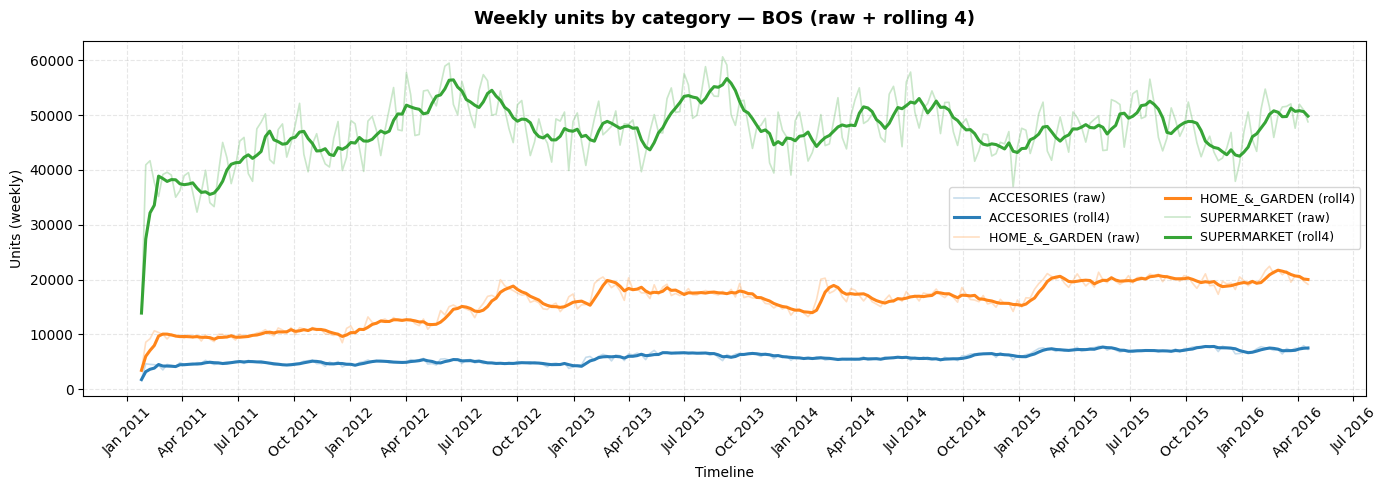

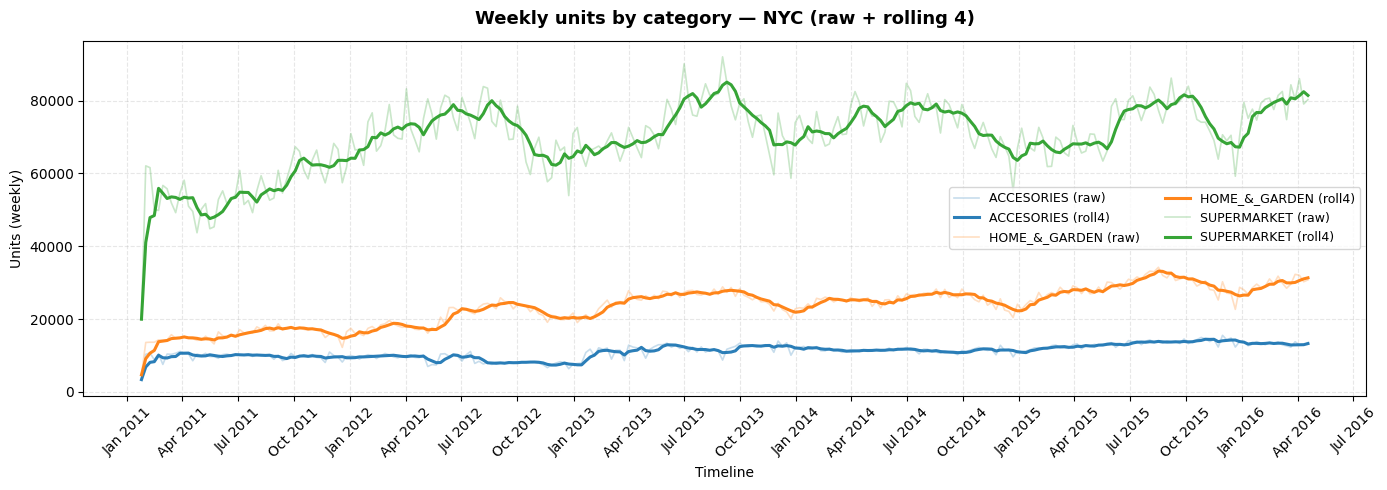

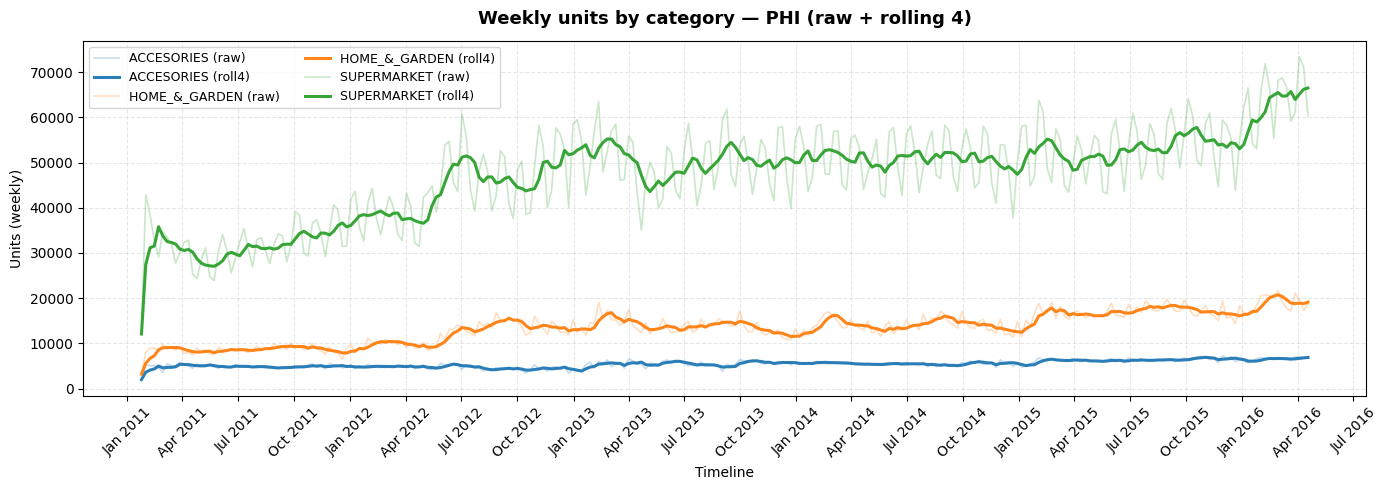

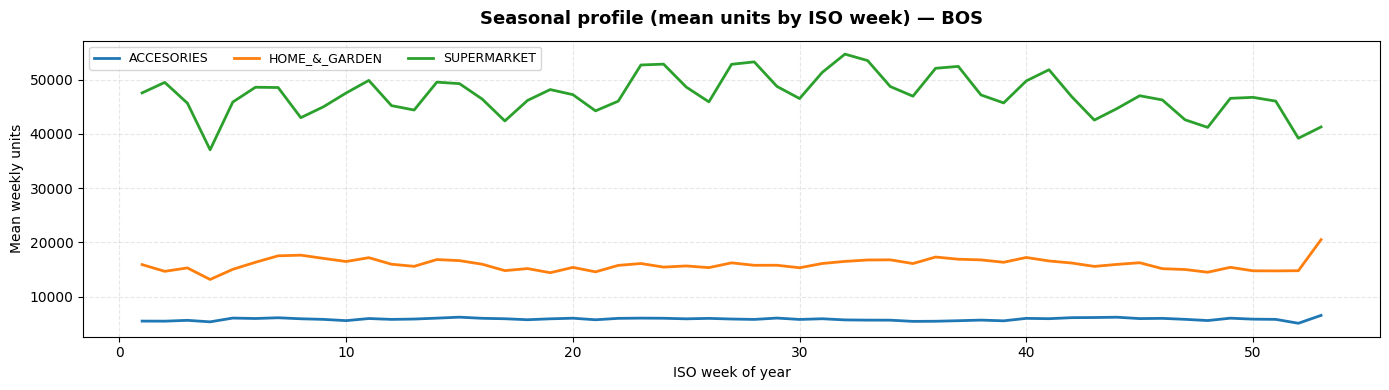

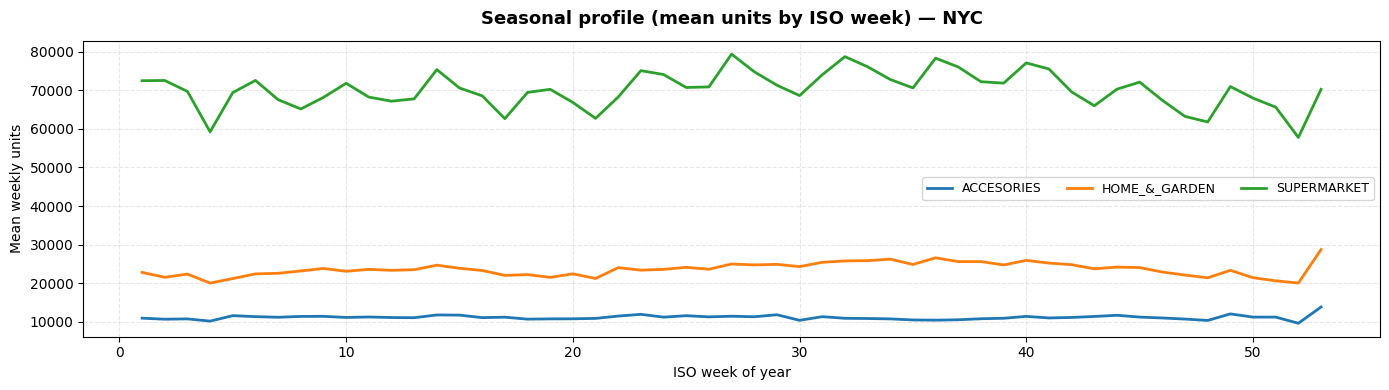

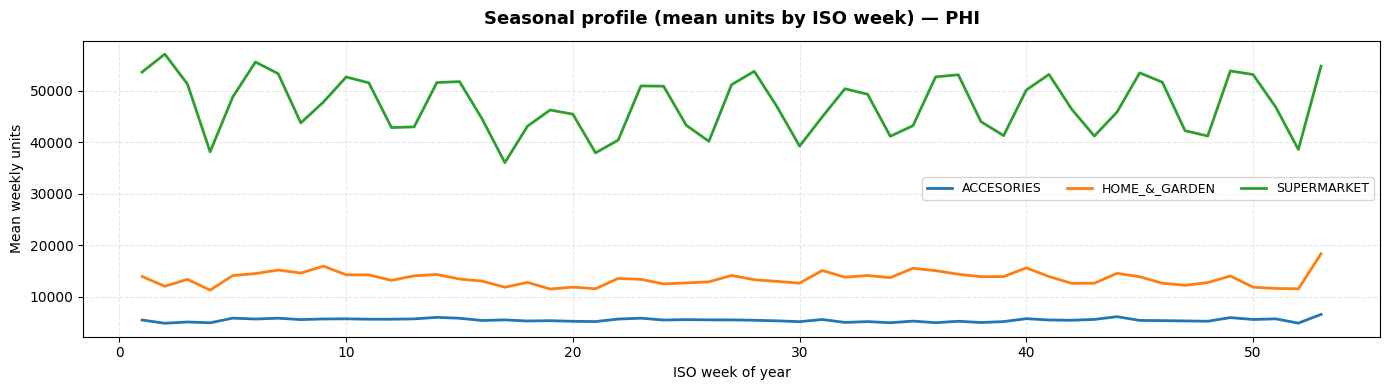


INTENCIONES:
1) Series auditadas: 9 (city×category).
2) Top 3 series con más semanas faltantes:
city      category  missing_%_vs_global
 BOS    ACCESORIES                 0.00
 BOS HOME_&_GARDEN                 0.00
 BOS   SUPERMARKET                 0.00
3) Siguiente paso: unir pricing a city×category×week y construir revenue proxy por segmento.


In [ ]:
# =============================================================================
# Auditoría temporal + plots (city × category × week)
# =============================================================================

import matplotlib.dates as mdates

required = {"city", "category", "yearweek", "week_dt", "units_week"}
missing = required - set(df_city_cat_weekly.columns)
if missing:
    raise ValueError(f"df_city_cat_weekly no tiene columnas requeridas: {missing}. Columnas actuales: {list(df_city_cat_weekly.columns)}")

df_ts = df_city_cat_weekly.copy()
df_ts = df_ts.sort_values(["city", "category", "week_dt"]).reset_index(drop=True)

all_weeks = pd.Series(sorted(df_ts["week_dt"].dropna().unique()))
n_all_weeks = len(all_weeks)

coverage = (
    df_ts.groupby(["city", "category"], observed=True, as_index=False)
    .agg(
        n_weeks=("week_dt", "nunique"),
        min_week=("week_dt", "min"),
        max_week=("week_dt", "max"),
        mean_units=("units_week", "mean"),
        std_units=("units_week", "std"),
    )
)

coverage["cv_units"] = (coverage["std_units"] / coverage["mean_units"]).replace([np.inf, -np.inf], np.nan)
coverage["missing_weeks_vs_global"] = n_all_weeks - coverage["n_weeks"]
coverage["missing_%_vs_global"] = (coverage["missing_weeks_vs_global"] / n_all_weeks * 100).round(2)

display(coverage.sort_values(["missing_%_vs_global", "mean_units"], ascending=[False, False]))

print(f"\n✅ Semanas globales observadas: {n_all_weeks}")
print(f"✅ Rango global: {all_weeks.min().date()} → {all_weeks.max().date()}")

ROLL = 4
cities = sorted(df_ts["city"].unique())
cats = sorted(df_ts["category"].unique())

for city in cities:
    d = df_ts[df_ts["city"] == city].copy()
    if d.empty:
        continue

    plt.figure(figsize=(14, 5))
    for cat in cats:
        dc = d[d["category"] == cat].copy()
        if dc.empty:
            continue

        line_raw, = plt.plot(dc["week_dt"], dc["units_week"], alpha=0.25, linewidth=1.2, label=f"{cat} (raw)")
        color = line_raw.get_color()

        plt.plot(
            dc["week_dt"],
            dc["units_week"].rolling(ROLL, min_periods=1).mean(),
            alpha=0.95,
            linewidth=2.2,
            color=color,
            label=f"{cat} (roll{ROLL})"
        )

    ax = plt.gca()
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

    plt.title(f"Weekly units by category — {city} (raw + rolling {ROLL})", fontsize=13, pad=12, fontweight="bold")
    plt.xlabel("Timeline")
    plt.ylabel("Units (weekly)")
    plt.grid(True, linestyle="--", alpha=0.30)
    plt.xticks(rotation=45)
    plt.legend(ncols=2, fontsize=9)
    plt.tight_layout()
    plt.show()

df_seas = df_ts.dropna(subset=["week_dt"]).copy()
df_seas["iso_week"] = df_seas["week_dt"].dt.isocalendar().week.astype(int)

for city in cities:
    d = df_seas[df_seas["city"] == city].copy()
    if d.empty:
        continue

    plt.figure(figsize=(14, 4))
    for cat in cats:
        dc = d[d["category"] == cat].copy()
        if dc.empty:
            continue

        seas = dc.groupby("iso_week", observed=True)["units_week"].mean().sort_index()
        plt.plot(seas.index, seas.values, linewidth=2.0, label=str(cat))

    plt.title(f"Seasonal profile (mean units by ISO week) — {city}", fontsize=13, pad=12, fontweight="bold")
    plt.xlabel("ISO week of year")
    plt.ylabel("Mean weekly units")
    plt.grid(True, linestyle="--", alpha=0.30)
    plt.legend(ncols=3, fontsize=9)
    plt.tight_layout()
    plt.show()

worst = coverage.sort_values("missing_%_vs_global", ascending=False).head(3)

print("\nINTENCIONES:")
print(f"1) Series auditadas: {len(coverage)} (city×category).")
print(f"2) Top 3 series con más semanas faltantes:\n{worst[['city','category','missing_%_vs_global']].to_string(index=False)}")
print("3) Siguiente paso: unir pricing a city×category×week y construir revenue proxy por segmento.")

<a id="priorizacion"></a>

## Priorización riesgo × impacto

A partir de aquí interpretamos el análisas a un lenguaje más útil para el negocio.

La idea es combinar:

- **Riesgo operativo**, medido en unidades.
- **Impacto económico proxy**, aproximado con precio medio semanal.

Esto permite identificar combinaciones **ciudad × categoría** donde una mala predicción
o una mala reposición podrían ser más costosas.

[⬆ Volver al índice](#indice)

In [ ]:
# =============================================================================
# Enriquecer city × category × week con precio medio + revenue proxy ($)
# =============================================================================

req_ts = {"city", "category", "yearweek", "week_dt", "units_week"}
req_p = {"item", "store_code", "yearweek", "sell_price"}
req_s = {"item", "category"}

miss_ts = req_ts - set(df_city_cat_weekly.columns)
miss_p = req_p - set(df_prices_clean.columns)
miss_s = req_s - set(df_sales.columns)

if miss_ts:
    raise ValueError(f"df_city_cat_weekly no tiene columnas requeridas: {miss_ts}")
if miss_p:
    raise ValueError(f"df_prices_clean no tiene columnas requeridas: {miss_p}")
if miss_s:
    raise ValueError(f"df_sales no tiene columnas requeridas para mapping item->category: {miss_s}")

df_item_cat = df_sales[["item", "category"]].drop_duplicates()

item_cat_counts = df_item_cat.groupby("item")["category"].nunique()
n_multi = int((item_cat_counts > 1).sum())

if n_multi > 0:
    print(f"⚠️ Aviso: {n_multi:,} items aparecen con más de 1 categoría. Usaremos la categoría modal por item.")
    tmp_mode = (
        df_sales[["item", "category"]]
        .groupby(["item", "category"], observed=True)
        .size()
        .reset_index(name="n")
        .sort_values(["item", "n"], ascending=[True, False])
        .drop_duplicates("item")
        .set_index("item")["category"]
    )
    item_to_cat = tmp_mode
else:
    item_to_cat = df_item_cat.set_index("item")["category"]

df_p = df_prices_clean.copy()

df_p["city"] = (
    df_p["store_code"].astype(str)
    .str.split("_", n=1, expand=True)[0]
    .str.upper()
    .str.strip()
)

df_p["category"] = df_p["item"].map(item_to_cat)

missing_cat = int(df_p["category"].isna().sum())
if missing_cat > 0:
    print(f"⚠️ Aviso: pricing con category NaN tras map(item->category): {missing_cat:,} filas.")

df_city_cat_price_weekly = (
    df_p.dropna(subset=["category"])
    .groupby(["city", "category", "yearweek"], observed=True, as_index=False)["sell_price"]
    .mean()
    .rename(columns={"sell_price": "avg_price_week"})
)

df_city_cat_weekly_enriched = df_city_cat_weekly.merge(
    df_city_cat_price_weekly,
    on=["city", "category", "yearweek"],
    how="left"
)

df_city_cat_weekly_enriched["revenue_week_proxy"] = (
    df_city_cat_weekly_enriched["units_week"] * df_city_cat_weekly_enriched["avg_price_week"]
)

n_rows = len(df_city_cat_weekly_enriched)
n_missing_price = int(df_city_cat_weekly_enriched["avg_price_week"].isna().sum())

print(f"✅ Shape enriched: {df_city_cat_weekly_enriched.shape}")
print(f"✅ Missing avg_price_week: {n_missing_price:,} ({n_missing_price/n_rows*100:.2f}%)")

missing_by_series = (
    df_city_cat_weekly_enriched.assign(price_missing=df_city_cat_weekly_enriched["avg_price_week"].isna())
    .groupby(["city", "category"], observed=True)["price_missing"]
    .mean()
    .mul(100)
    .round(2)
    .to_frame("pct_weeks_missing_price")
    .sort_values("pct_weeks_missing_price", ascending=False)
)
display(missing_by_series)

display(df_city_cat_weekly_enriched.head(5))

print("\nINTENCIONES:")
print("1) city×category×week enriquecido con precio medio semanal (proxy) y revenue ($ proxy).")
print("2) Esto habilita priorización dual por segmento (riesgo en unidades × impacto en $).")
print("3) Siguiente paso: construir ranking y exportables Power BI.")

✅ Shape enriched: (2466, 7)
✅ Missing avg_price_week: 18 (0.73%)


pct_weeks_missing_price
city category                              
BOS  ACCESORIES                        0.73
     HOME_&_GARDEN                     0.73
     SUPERMARKET                       0.73
NYC  ACCESORIES                        0.73
     HOME_&_GARDEN                     0.73
     SUPERMARKET                       0.73
PHI  ACCESORIES                        0.73
     HOME_&_GARDEN                     0.73
     SUPERMARKET                       0.73

,city,category,yearweek,week_dt,units_week,avg_price_week,revenue_week_proxy
0,BOS,ACCESORIES,201104,2011-01-24,1749,NaN,NaN
1,BOS,ACCESORIES,201105,2011-01-31,4636,6.25,"28,993.77"
2,BOS,ACCESORIES,201106,2011-02-07,4528,6.22,"28,169.87"
3,BOS,ACCESORIES,201107,2011-02-14,4467,6.18,"27,596.24"
4,BOS,ACCESORIES,201108,2011-02-21,4379,6.13,"26,864.70"



INTENCIONES:
1) city×category×week enriquecido con precio medio semanal (proxy) y revenue ($ proxy).
2) Esto habilita priorización dual por segmento (riesgo en unidades × impacto en $).
3) Siguiente paso: construir ranking y exportables Power BI.


,city,category,n_weeks,sum_units,mean_units,median_units,std_units,p95_units,wow_abs_mean,sum_rev_proxy,mean_rev_proxy,cv_units,peak_ratio_p95_med,wow_abs_rel,r_cv,r_peak,r_wow,risk_score,rev_share_global,rev_share_city,priority_score_usd_proxy
0,PHI,SUPERMARKET,274,"12,937,216.00","47,216.12","47,539.50","10,579.38","61,819.70","6,145.67","50,470,831.77","184,200.12",0.22,1.30,0.13,0.75,0.75,1.00,0.80,0.16,0.59,0.13
1,PHI,HOME_&_GARDEN,274,"3,691,062.00","13,471.03","13,660.00","3,404.54","18,982.95","1,279.47","25,094,285.55","91,584.98",0.25,1.39,0.09,1.00,1.00,0.88,0.98,0.08,0.29,0.08
2,NYC,HOME_&_GARDEN,274,"6,439,362.00","23,501.32","24,725.50","5,237.50","30,990.10","1,186.93","43,811,391.49","159,895.59",0.22,1.25,0.05,0.62,0.62,0.00,0.50,0.14,0.31,0.07
3,BOS,HOME_&_GARDEN,274,"4,350,246.00","15,876.81","16,681.50","3,703.06","20,713.35",904.15,"29,493,132.01","107,639.17",0.23,1.24,0.06,0.88,0.38,0.12,0.58,0.09,0.33,0.05
4,NYC,SUPERMARKET,274,"19,196,302.00","70,059.50","70,855.00","9,709.59","82,614.60","4,694.86","74,000,326.98","270,074.19",0.14,1.17,0.07,0.12,0.12,0.38,0.18,0.23,0.53,0.04
5,NYC,ACCESORIES,274,"3,039,883.00","11,094.46","11,349.50","1,923.40","13,932.60",791.17,"21,292,234.61","77,708.89",0.17,1.23,0.07,0.38,0.25,0.50,0.36,0.07,0.15,0.02
6,BOS,SUPERMARKET,274,"12,956,421.00","47,286.21","47,593.50","5,627.04","55,405.65","3,704.29","49,878,300.18","182,037.59",0.12,1.16,0.08,0.00,0.00,0.62,0.12,0.16,0.55,0.02
7,BOS,ACCESORIES,274,"1,592,339.00","5,811.46","5,637.50","1,067.85","7,593.10",337.08,"11,049,791.22","40,327.71",0.18,1.35,0.06,0.50,0.88,0.25,0.56,0.04,0.12,0.02
8,PHI,ACCESORIES,274,"1,492,578.00","5,447.36","5,381.00",803.08,"6,718.25",435.08,"10,433,814.83","38,079.62",0.15,1.25,0.08,0.25,0.50,0.75,0.43,0.03,0.12,0.01


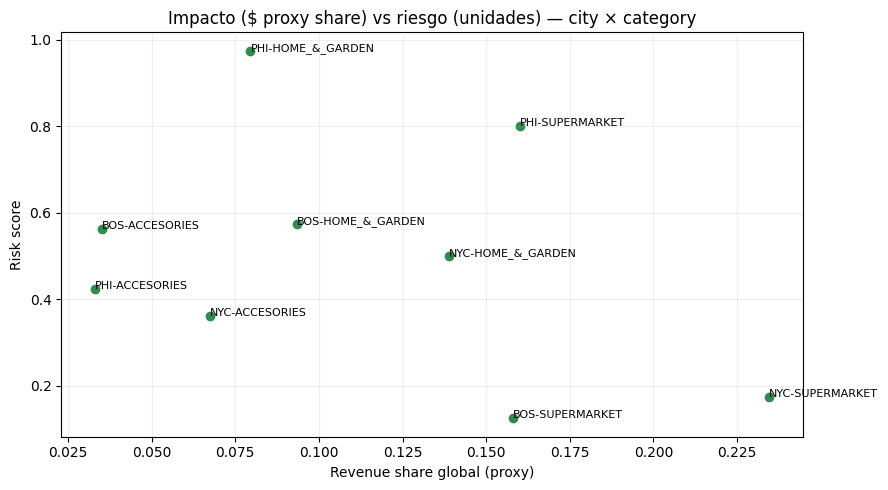

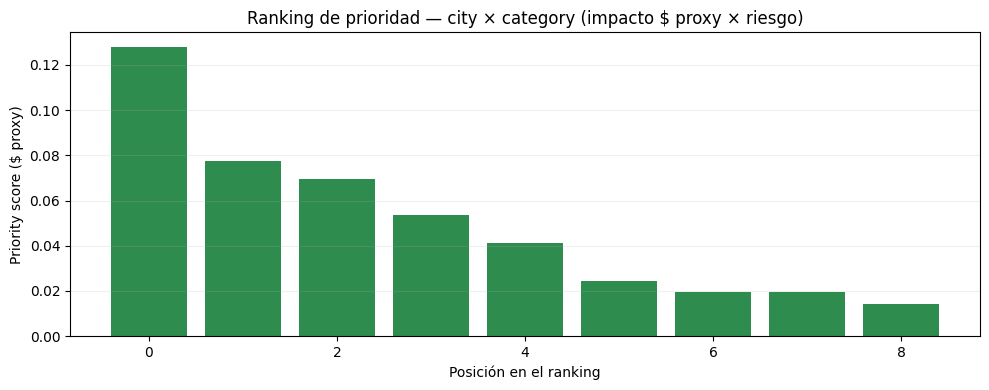


MINI-CONCLUSIÓN (Tarea 1):
1) TOP-3 segmentos por prioridad ($ proxy × riesgo):
city      category  priority_score_usd_proxy  risk_score  rev_share_global
 PHI   SUPERMARKET                      0.13        0.80              0.16
 PHI HOME_&_GARDEN                      0.08        0.98              0.08
 NYC HOME_&_GARDEN                      0.07        0.50              0.14
2) Nota: $ proxy = units × avg_price_week (precio no ponderado por mix exacto).
3) Siguiente paso: exportar tablas para Power BI.


In [ ]:
# =============================================================================
# Demand Profiles + ranking de prioridad (city × category) — $ proxy
# =============================================================================

required = {"city", "category", "week_dt", "units_week", "revenue_week_proxy"}
missing = required - set(df_city_cat_weekly_enriched.columns)

if missing:
    raise ValueError(
        f"df_city_cat_weekly_enriched no tiene columnas requeridas: {missing}. "
        f"Columnas actuales: {list(df_city_cat_weekly_enriched.columns)}"
    )

df_ts = (
    df_city_cat_weekly_enriched[["city", "category", "week_dt", "units_week", "revenue_week_proxy"]]
    .copy()
    .sort_values(["city", "category", "week_dt"])
    .reset_index(drop=True)
)

def _safe_div(a, b):
    return np.where(b == 0, np.nan, a / b)

def _rank01(s: pd.Series) -> pd.Series:
    r = s.rank(method="average", ascending=True)
    return (r - r.min()) / (r.max() - r.min()) if r.max() != r.min() else 0.0

rows = []
for (city, cat), d in df_ts.groupby(["city", "category"], observed=True):
    x = d["units_week"].astype(float)
    rev = d["revenue_week_proxy"].astype(float)

    rows.append({
        "city": city,
        "category": cat,
        "n_weeks": int(d["week_dt"].nunique()),
        "sum_units": x.sum(),
        "mean_units": x.mean(),
        "median_units": x.median(),
        "std_units": x.std(),
        "p95_units": x.quantile(0.95),
        "wow_abs_mean": x.diff().abs().mean(),
        "sum_rev_proxy": np.nan_to_num(rev, nan=0.0).sum(),
        "mean_rev_proxy": np.nan_to_num(rev, nan=0.0).mean(),
    })

df_profile = pd.DataFrame(rows)

df_profile["cv_units"] = _safe_div(df_profile["std_units"], df_profile["mean_units"])
df_profile["peak_ratio_p95_med"] = _safe_div(df_profile["p95_units"], df_profile["median_units"])
df_profile["wow_abs_rel"] = _safe_div(df_profile["wow_abs_mean"], df_profile["mean_units"])

df_profile["r_cv"] = _rank01(df_profile["cv_units"].fillna(0))
df_profile["r_peak"] = _rank01(df_profile["peak_ratio_p95_med"].fillna(0))
df_profile["r_wow"] = _rank01(df_profile["wow_abs_rel"].fillna(0))

df_profile["risk_score"] = 0.5 * df_profile["r_cv"] + 0.3 * df_profile["r_peak"] + 0.2 * df_profile["r_wow"]

total_rev = df_profile["sum_rev_proxy"].sum()
df_profile["rev_share_global"] = df_profile["sum_rev_proxy"] / total_rev if total_rev != 0 else np.nan
df_profile["rev_share_city"] = df_profile["sum_rev_proxy"] / df_profile.groupby("city", observed=True)["sum_rev_proxy"].transform("sum")

df_profile["priority_score_usd_proxy"] = df_profile["rev_share_global"] * df_profile["risk_score"]

df_profile_rev_rank = (
    df_profile.sort_values("priority_score_usd_proxy", ascending=False)
    .reset_index(drop=True)
)

display(df_profile_rev_rank)

plt.figure(figsize=(9, 5))
plt.scatter(
    df_profile_rev_rank["rev_share_global"],
    df_profile_rev_rank["risk_score"],
    color=COLORS["primary"]
)

for _, r in df_profile_rev_rank.iterrows():
    plt.text(r["rev_share_global"], r["risk_score"], f"{r['city']}-{r['category']}", fontsize=8)

plt.title("Impacto ($ proxy share) vs riesgo (unidades) — city × category")
plt.xlabel("Revenue share global (proxy)")
plt.ylabel("Risk score")
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(
    range(len(df_profile_rev_rank)),
    df_profile_rev_rank["priority_score_usd_proxy"].values,
    color=COLORS["primary"]
)
plt.title("Ranking de prioridad — city × category (impacto $ proxy × riesgo)")
plt.xlabel("Posición en el ranking")
plt.ylabel("Priority score ($ proxy)")
plt.grid(True, axis="y", alpha=0.2)
plt.tight_layout()
plt.show()

top3 = df_profile_rev_rank.head(3)[["city", "category", "priority_score_usd_proxy", "risk_score", "rev_share_global"]]

print("\nMINI-CONCLUSIÓN (Tarea 1):")
print("1) TOP-3 segmentos por prioridad ($ proxy × riesgo):")
print(top3.to_string(index=False))
print("2) Nota: $ proxy = units × avg_price_week (precio no ponderado por mix exacto).")
print("3) Siguiente paso: exportar tablas para Power BI.")

<a id="exportables"></a>

## Exportables.

En lugar de exportar el nivel más granular posible, congelamos una capa semanal ligera
y reutilizable para exploración ejecutiva y Power BI.

La idea aquí no es construir un sistema BI completo,
sino dejar una base limpia para reporting posterior.

[⬆ Volver al índice](#indice)

In [ ]:
# =============================================================================
# Export CSVs para Power BI (estrella, ligero y reproducible)
# =============================================================================

from pathlib import Path

EXPORT_DIR = Path("./pbi_exports")
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

req_fact = {"city", "category", "yearweek", "week_dt", "units_week", "avg_price_week", "revenue_week_proxy"}
missing = req_fact - set(df_city_cat_weekly_enriched.columns)

if missing:
    raise ValueError(
        f"df_city_cat_weekly_enriched no tiene columnas requeridas: {missing}. "
        f"Columnas actuales: {list(df_city_cat_weekly_enriched.columns)}"
    )

fact_city_cat_week = df_city_cat_weekly_enriched[
    ["city", "category", "yearweek", "week_dt", "units_week", "avg_price_week", "revenue_week_proxy"]
].copy()

iso = fact_city_cat_week["week_dt"].dt.isocalendar()
fact_city_cat_week["iso_year"] = iso["year"].astype(int)
fact_city_cat_week["iso_week"] = iso["week"].astype(int)
fact_city_cat_week["year"] = fact_city_cat_week["week_dt"].dt.year.astype(int)
fact_city_cat_week["month"] = fact_city_cat_week["week_dt"].dt.month.astype(int)
fact_city_cat_week["quarter"] = fact_city_cat_week["week_dt"].dt.quarter.astype(int)

dup_keys = fact_city_cat_week.duplicated(["city", "category", "yearweek"]).sum()
if dup_keys > 0:
    raise ValueError(f"Hay duplicados en la clave (city, category, yearweek): {dup_keys}")

fact_city_cat_week.to_csv(EXPORT_DIR / "fact_city_cat_week.csv", index=False)

dim_week = (
    fact_city_cat_week[["yearweek", "week_dt", "iso_year", "iso_week", "year", "month", "quarter"]]
    .drop_duplicates()
    .sort_values("week_dt")
    .reset_index(drop=True)
)
dim_week.to_csv(EXPORT_DIR / "dim_week.csv", index=False)

dim_city = pd.DataFrame({"city": sorted(fact_city_cat_week["city"].unique())})
dim_city.to_csv(EXPORT_DIR / "dim_city.csv", index=False)

dim_category = pd.DataFrame({"category": sorted(fact_city_cat_week["category"].unique())})
dim_category.to_csv(EXPORT_DIR / "dim_category.csv", index=False)

priority_cols = ["city", "category", "risk_score", "rev_share_global", "priority_score_usd_proxy"]
missing_p = [c for c in priority_cols if c not in df_profile_rev_rank.columns]

if missing_p:
    raise ValueError(
        f"df_profile_rev_rank no tiene columnas requeridas: {missing_p}. "
        f"Columnas actuales: {list(df_profile_rev_rank.columns)}"
    )

profile_priority = df_profile_rev_rank[priority_cols].copy()
profile_priority.to_csv(EXPORT_DIR / "profile_priority.csv", index=False)

if "df_city_weekly_enriched" in globals():
    cols_cw = set(df_city_weekly_enriched.columns)
    needed_cw = {"city", "yearweek"}

    if needed_cw.issubset(cols_cw):
        units_col = "units_week" if "units_week" in cols_cw else None

        if units_col is not None:
            cw = df_city_weekly_enriched.copy()

            if "week_dt" not in cols_cw:
                s = cw["yearweek"].astype(str).str.zfill(6)
                cw["week_dt"] = pd.to_datetime(
                    s.str[:4] + "-W" + s.str[4:] + "-1",
                    format="%G-W%V-%u",
                    errors="coerce"
                )

            fact_city_week = cw[["city", "yearweek", "week_dt", units_col]].copy().rename(columns={units_col: "units_week"})

            for extra in ["avg_price_week", "revenue_week_proxy"]:
                if extra in cols_cw:
                    fact_city_week[extra] = cw[extra]

            dup_cw = fact_city_week.duplicated(["city", "yearweek"]).sum()
            if dup_cw > 0:
                raise ValueError(f"Duplicados en (city, yearweek) en fact_city_week: {dup_cw}")

            fact_city_week.to_csv(EXPORT_DIR / "fact_city_week.csv", index=False)
            print("✅ Export adicional: fact_city_week.csv")

print("✅ Export OK — Archivos en:", EXPORT_DIR.resolve())
print("fact_city_cat_week:", fact_city_cat_week.shape)
print("dim_week:", dim_week.shape)
print("dim_city:", dim_city.shape)
print("dim_category:", dim_category.shape)
print("profile_priority:", profile_priority.shape)

null_price = int(fact_city_cat_week["avg_price_week"].isna().sum())
print(f"ℹ️ avg_price_week nulls (fact): {null_price:,} ({null_price/len(fact_city_cat_week)*100:.2f}%)")

✅ Export adicional: fact_city_week.csv
✅ Export OK — Archivos en: /kaggle/working/pbi_exports
fact_city_cat_week: (2466, 12)
dim_week: (274, 7)
dim_city: (3, 1)
dim_category: (3, 1)
profile_priority: (9, 5)
ℹ️ avg_price_week nulls (fact): 18 (0.73%)


<a id="cierre-ejecutivo"></a>

## Cierre ejecutivo

<div style="background-color:#2d8c4e;border-left:6px solid #F4A261;padding:14px;border-radius:10px">

### Lectura de negocio

A nivel agregado, la demanda de DSMarket muestra una estructura temporal reconocible
y diferencias relevantes entre ciudades y categorías.

Cuando bajamos al nivel **ciudad × categoría × semana** aparecen combinaciones
con distinto perfil de volumen, variabilidad y peso económico proxy.
Eso confirma que no conviene tratar toda la demanda como si fuera homogénea.

El análisis de pricing a nivel agregado sugiere prudencia:
el precio medio semanal sirve como proxy ejecutivo,
pero no como evidencia suficiente para explicar por sí solo la demanda.

### Qué decisión cambia este análisis

Este EDA deja una base clara para las siguientes tareas del proyecto:

- Conservar granularidad suficiente para forecasting.
- Priorizar segmentos con mayor impacto y riesgo.
- Conectar más adelante la predicción con una lógica operativa de reposición.

Además, se congela una capa semanal ligera y reutilizable
que puede usarse en Power BI sin necesidad de explotar el nivel item-store-day.

</div>

[⬆ Volver al índice](#indice)